In the list add proper known monomners for testing reactions

In [28]:
sample_smiles = [
            "O=C(O)CCCCCO"       
            ]

In [29]:
from rdkit import Chem
for s in sample_smiles:
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        raise ValueError(f"SMILES '{s}' is invalid (RDKit could not parse it).")


Define your required monomers functionality 

In [30]:
monomers = {
    "hydroxy_acyl_chlorides_monomer": {
        "functionality_type": "di_different",
        "smarts_1": "[OX2H1;!$(OC=*):1]",
        "smarts_2": "[CX3:2](=[O])[Cl,Br,I,OX2H1]",
        "group_name": "hydroxy_carboxylic_acid"
}
}


In [31]:
for funct in monomers.values():
    functionality_type = funct["functionality_type"]
    if functionality_type is None:
        raise ValueError("Functionality type is missing.")
    if functionality_type not in ["di_identical", "di_different", "mono", "vinyl"]:
        raise ValueError(f"Functionality type '{functionality_type}' is invalid.")
    if "smarts_1" not in funct:
        raise ValueError("Missing 'smarts_1' must be provided.")
    smart_1 = funct.get("smarts_1")
    if Chem.MolFromSmarts(smart_1) is None:
        raise ValueError(f"'smarts_1' '{smart_1}' is invalid.")
    if functionality_type == "di_different":
        smart_2 = funct.get("smarts_2")
        if smart_2 is None:
            raise ValueError("Missing 'smarts_2' for 'di_different' functionality type.")
        if Chem.MolFromSmarts(smart_2) is None:
            raise ValueError(f"'smarts_2' '{smart_2}' is invalid.")
    if "group_name" not in funct:
        raise ValueError("Missing 'group_name' must be provided.")
    group_name = funct.get("group_name")
    if not isinstance(group_name, str) or not group_name.strip():
        raise ValueError(f"'group_name' '{group_name}' is invalid.")
    print(f"{group_name} definitions are valid.")
    

hydroxy_carboxylic_acid definitions are valid.


Testing Function Block

In [32]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

def validate_functional_group(sample_smiles: list[str], monomers: dict[str, dict[str, str]]):
    results = []

    for monomer_1_smiles in sample_smiles:
        mol_1 = Chem.MolFromSmiles(monomer_1_smiles)
        if mol_1 is None:
            print(f"Skipping invalid SMILES: {monomer_1_smiles}")
            continue

        # make explicit Hs (MUST assign)
        mol_1 = Chem.AddHs(mol_1)

        for funtionality in monomers.values():

            if funtionality["functionality_type"] == "di_different":
                smarts_1 = Chem.MolFromSmarts(funtionality["smarts_1"])
                smarts_2 = Chem.MolFromSmarts(funtionality["smarts_2"])
                if smarts_1 is None or smarts_2 is None:
                    continue

                if mol_1.HasSubstructMatch(smarts_1) and mol_1.HasSubstructMatch(smarts_2):
                    print(f"Monomer {monomer_1_smiles} matches functionality {funtionality['group_name']}")
                    print("Different functional passed.")

                    # get *all* matches (not just first) so highlight is complete
                    matches_1 = mol_1.GetSubstructMatches(smarts_1)
                    matches_2 = mol_1.GetSubstructMatches(smarts_2)

                    atoms_to_highlight = []
                    for m in matches_1:
                        atoms_to_highlight.extend(list(m))
                    for m in matches_2:
                        atoms_to_highlight.extend(list(m))

                    # dedupe + keep order-ish
                    atoms_to_highlight = list(dict.fromkeys(atoms_to_highlight))

                    results.append((mol_1, atoms_to_highlight, funtionality["group_name"]))

            if funtionality["functionality_type"] == "di_identical":
                smarts_1 = Chem.MolFromSmarts(funtionality["smarts_1"])
                if smarts_1 is None:
                    continue

                matches = mol_1.GetSubstructMatches(smarts_1)
                if len(matches) >= 2:
                    print(f"Monomer {monomer_1_smiles} matches functionality {funtionality['group_name']}")
                    print("Identical functional passed.")

                    atoms_to_highlight = []
                    for match in matches:
                        atoms_to_highlight.extend(list(match))
                    atoms_to_highlight = list(dict.fromkeys(atoms_to_highlight))

                    results.append((mol_1, atoms_to_highlight, funtionality["group_name"]))

    if not results:
        raise ValueError("No matching functional group found.")
    return results





Test the detect_reactions function

Monomer O=C(O)CCCCCO matches functionality hydroxy_carboxylic_acid
Different functional passed.


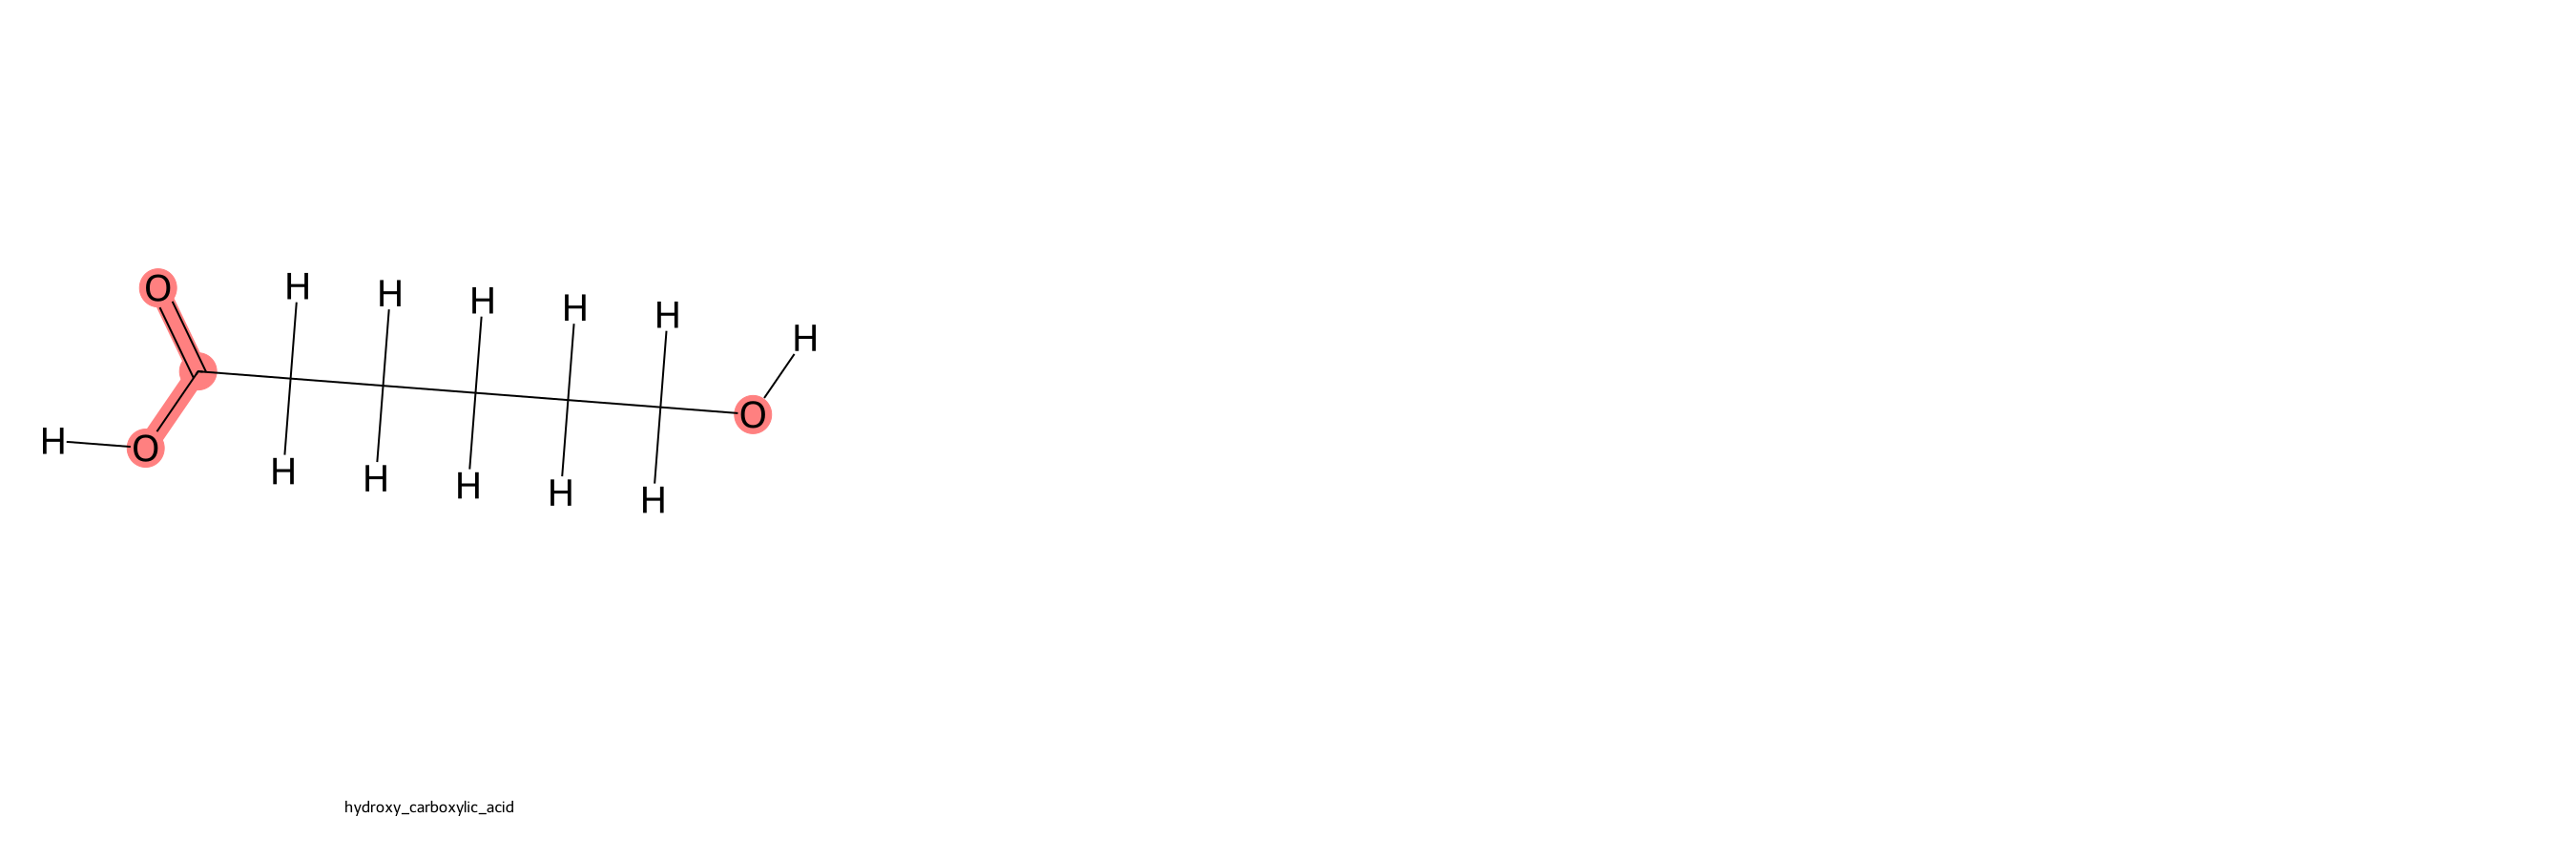

In [33]:
# --- generate + save ALL images with explicit Hs ---
results = validate_functional_group(sample_smiles, monomers)



# Create a grid from the molecules and highlights directly
grid_img = Draw.MolsToGridImage(
    [r[0] for r in results], 
    molsPerRow=3, 
    subImgSize=(900, 900),
    highlightAtomLists=[r[1] for r in results],
    legends=[r[2] for r in results]
)

display(grid_img)

In [34]:
reactions_definitions = {
    "Hydroxy Carboxylic Acid Polycondensation(Polyesterification)": {
        "same_reactants": True,
        "reactant_1": "hydroxy_carboxylic_acid",
        "product": "polyester_chain",
        "delete_atom": True,
        "reaction": "[O;!$(OC=*):1]-[H:3].[CX3:2](=[O:5])[OX2H1:4]>>[OX2:1]-[CX3:2](=[O:5]).[O:4]-[H:3]",
        "reference": {"smarts": ["https://pubs.acs.org/doi/10.1021/acs.jcim.3c00329"],
                      "reaction_and_mechanism": ["https://pubs.acs.org/doi/10.1021/ed048pA734.1", 
                                                 "https://pubs.acs.org/doi/10.1021/ed073pA312"]}
    }
}

In [35]:
from rdkit import Chem
from rdkit.Chem import rdChemReactions
import json
def validate_reaction_smarts(smarts_string):
    """
    Validates a reaction SMARTS string using RDKit.
    Returns True if valid, False otherwise.
    """
    try:
        # Attempt to create a reaction object from the SMARTS string
        rxn = rdChemReactions.ReactionFromSmarts(smarts_string)
        
        # If the above line runs without error, the SMARTS is syntactically valid
        if rxn is not None:
            print(f"'{smarts_string}' is a valid reaction SMARTS.")
            return True
        else:
            # Handle cases where no exception is raised, but the object is None
            print(f"'{smarts_string}' is an invalid reaction SMARTS (returned None).")
            return False
    except Exception as e:
        # If an exception is caught, the SMARTS is invalid
        print(f"'{smarts_string}' is an invalid reaction SMARTS.")
        # Optional: print the error message for debugging
        # print(f"Error details: {e}")
        return False
    
def are_all_atoms_mapped(reaction_smarts):
    rxn = rdChemReactions.ReactionFromSmarts(reaction_smarts)
    if rxn is None:
        return False, "Invalid reaction SMARTS"

    # Check reactants
    for reactant_mol in rxn.GetReactants():
        for atom in reactant_mol.GetAtoms():
            if atom.GetAtomMapNum() == 0:
                return False, "Unmapped atom found in reactants"
    
    # Check products
    for product_mol in rxn.GetProducts():
        for atom in product_mol.GetAtoms():
            if atom.GetAtomMapNum() == 0:
                return False, "Unmapped atom found in products"

    return True, "All atoms are mapped"

for reaction in reactions_definitions.values():
    reaction_smarts = reaction.get("reaction")
    same_reactants = reaction.get("same_reactants")
    reactant_1 = reaction.get("reactant_1")
    product = reaction.get("product")
    delete_atom = reaction.get("delete_atom")
    reference = reaction.get("reference")
    if same_reactants is None:
        raise ValueError("Same reactants flag is missing.")
    if reactant_1 is None:
        raise ValueError("Reactant 1 information is missing.")
    if not same_reactants:
        reactant_2 = reaction.get("reactant_2")
        if reactant_2 is None:
            raise ValueError("Reactant 2 information is missing for different reactants.")
    if product is None:
        raise ValueError("Product information is missing.")
    if delete_atom is None:
        raise ValueError("Delete atom flag is missing.")
    if reaction_smarts is None:
        raise ValueError("Reaction SMARTS is missing.")
    validate_reaction_smarts(reaction_smarts)
    is_mapped, message = are_all_atoms_mapped(reaction_smarts)
    if not is_mapped:
        raise ValueError(f"Reaction SMARTS '{reaction_smarts}' has unmapped atoms: {message}")
    if reference is None:
        print("Warning: Reference information is missing.")
    smarts_ref = reference.get("smarts")
reaction_and_mechanism = reference.get("reaction_and_mechanism")

# Required: both must be lists (or None if you want to allow missing)
if smarts_ref is None or reaction_and_mechanism is None:
    print("Warning: Reference information is missing ('smarts' or 'reaction_and_mechanism').")
else:
    if smarts_ref:
        if not isinstance(smarts_ref, list):
            print("Warning: 'smarts' is not a list.")
            raise ValueError("'smarts' should be a list.")
        # Optional: enforce list-of-strings
        if not all(isinstance(url, str) for url in smarts_ref):
            print("'smarts' should be a list of strings.")
        # Optional: enforce URLs
        bad_urls = [url for url in smarts_ref if not url.startswith("http")]
        if bad_urls:
            print("Warning: Some reference URLs do not start with 'http':")
            for u in bad_urls:
                print(" -", u)
    if reaction_and_mechanism:
        if not isinstance(reaction_and_mechanism, list):
            print("Warning: 'reaction_and_mechanism' is not a list.")
            raise ValueError("'reaction_and_mechanism' should be a list.")
        # Optional: enforce list-of-strings
        if not all(isinstance(url, str) for url in reaction_and_mechanism):
            print("'reaction_and_mechanism' should be a list of strings.")
        # Optional: enforce URLs
        bad_urls = [url for url in reaction_and_mechanism if not url.startswith("http")]
        if bad_urls:
            print("Warning: Some reference URLs do not start with 'http':")
            for u in bad_urls:
                print(" -", u)

print(f"{json.dumps(reaction, indent=2)}")
print("Reaction definition is valid.")

'[O;!$(OC=*):1]-[H:3].[CX3:2](=[O:5])[OX2H1:4]>>[OX2:1]-[CX3:2](=[O:5]).[O:4]-[H:3]' is a valid reaction SMARTS.
{
  "same_reactants": true,
  "reactant_1": "hydroxy_carboxylic_acid",
  "product": "polyester_chain",
  "delete_atom": true,
  "reaction": "[O;!$(OC=*):1]-[H:3].[CX3:2](=[O:5])[OX2H1:4]>>[OX2:1]-[CX3:2](=[O:5]).[O:4]-[H:3]",
  "reference": {
    "smarts": [
      "https://pubs.acs.org/doi/10.1021/acs.jcim.3c00329"
    ],
    "reaction_and_mechanism": [
      "https://pubs.acs.org/doi/10.1021/ed048pA734.1",
      "https://pubs.acs.org/doi/10.1021/ed073pA312"
    ]
  }
}
Reaction definition is valid.


In [40]:
def smart_mapping(reactant, smarts_template, match_tuple):
    """
    Apply atom mapping from SMARTS template to reactant molecule based on match indices.
    
    This function transfers atom map numbers from a SMARTS template to corresponding
    atoms in the reactant molecule using the provided match tuple that maps SMARTS
    atom indices to reactant atom indices.
    
    Args:
        reactant (Chem.Mol): The reactant molecule to apply mapping to
        smarts_template (Chem.Mol): SMARTS pattern molecule with atom map numbers
        match_tuple (tuple): Tuple mapping SMARTS atom indices to reactant atom indices
        
    Returns:
        None: Modifies the reactant molecule in-place by setting atom map numbers
        
    Note:
        Only atoms with non-zero map numbers in the SMARTS template are processed.
        The function does nothing if match_tuple is empty.
    """
    if not match_tuple:
        return
    
    # Create mapping from SMARTS atom indices to their map numbers
    SMARTS_index_to_Map_Number = {}
    for smarts_atom in smarts_template.GetAtoms():
        map_num = smarts_atom.GetAtomMapNum()
        if map_num != 0:  # Only process atoms with explicit mapping
            SMARTS_index_to_Map_Number[smarts_atom.GetIdx()] = map_num
    
    # Apply mapping to corresponding atoms in reactant
    for smarts_pos, map_num in SMARTS_index_to_Map_Number.items():
        if smarts_pos < len(match_tuple):
            atom_index_in_mol = match_tuple[smarts_pos]
            atom = reactant.GetAtomWithIdx(atom_index_in_mol)
            atom.SetAtomMapNum(map_num)

def build_reaction(rxn_smarts):
    """
    Create an RDKit reaction object from SMARTS string.
    
    Args:
        rxn_smarts (str): Reaction SMARTS string
        
    Returns:
        Chem.rdChemReactions.ChemicalReaction: RDKit reaction object
        
    Example:
        >>> rxn = build_reaction("[C:1]=[O:2]>>[C:1]-[O:2]")
    """
    return AllChem.ReactionFromSmarts(rxn_smarts)

def build_reactants(reactant_smiles_1, reactant_smiles_2):
    """
    Create RDKit molecule objects from SMILES strings with explicit hydrogens.
    
    Args:
        reactant_smiles_1 (str): SMILES string for first reactant
        reactant_smiles_2 (str): SMILES string for second reactant
        
    Returns:
        tuple: (mol_reactant_1, mol_reactant_2) - Both molecules with explicit hydrogens
        
    Example:
        >>> mol1, mol2 = build_reactants("CCO", "CC=O")
    """
    mol_reactant_1 = Chem.MolFromSmiles(reactant_smiles_1)
    mol_reactant_1 = Chem.AddHs(mol_reactant_1)  # Add explicit hydrogens
    mol_reactant_2 = Chem.MolFromSmiles(reactant_smiles_2)
    mol_reactant_2 = Chem.AddHs(mol_reactant_2)  # Add explicit hydrogens
    return mol_reactant_1, mol_reactant_2

def reaction_tuples(same_reactants, mol_reactant_1, mol_reactant_2):
    """
    Generate reactant pair orderings for reaction processing.

    - For same reactants: only one unique ordering [A, A].
    - For different reactants: return both [A, B] and [B, A] to avoid relying
      on reactant ordering and to support order-dependent reaction definitions.
    """
    if same_reactants:
        return [[mol_reactant_1, mol_reactant_1]]

    return [[mol_reactant_1, mol_reactant_2], [mol_reactant_2, mol_reactant_1]]

def map_reactant_atoms(rxn_smarts, same_reactants, reactant_smiles_1, reactant_smiles_2=None):
    """
    Map reactant atoms based on reaction SMARTS and reactant SMILES.

    Args:
        rxn_smarts (str): Reaction SMARTS string
        same_reactants (bool): Flag indicating if reactants are the same
        reactant_smiles_1 (str): SMILES string for first reactant
        reactant_smiles_2 (str, optional): SMILES string for second reactant if different
    Returns:
        list: List of tuples containing mapped reactant molecules
    """
    rxn = build_reaction(rxn_smarts)
    mol_reactant_1, mol_reactant_2 = build_reactants(reactant_smiles_1, reactant_smiles_2)
    mapped_reactant_tuples = []

    for reactant_pair in reaction_tuples(same_reactants, mol_reactant_1, mol_reactant_2):
        mol_1 = reactant_pair[0]
        mol_2 = reactant_pair[1]

        smarts_reactant_1 = rxn.GetReactants()[0]
        smarts_reactant_2 = rxn.GetReactants()[1]

        matches_1 = mol_1.GetSubstructMatches(smarts_reactant_1)
        matches_2 = mol_2.GetSubstructMatches(smarts_reactant_2)

        if not matches_1 or not matches_2:
            continue

        # For simplicity, use the first match found
        match_1 = matches_1[0]
        match_2 = matches_2[0]

        smart_mapping(mol_1, smarts_reactant_1, match_1)
        smart_mapping(mol_2, smarts_reactant_2, match_2)

        mapped_reactant_tuples.append((mol_1, mol_2))

        products = rxn.RunReactants((mol_1, mol_2))
        if not products:
            continue
        else:
            print("Reaction produced products.")
            return mapped_reactant_tuples, products

    if not mapped_reactant_tuples:
        raise ValueError("No valid substructure matches found for reactants.")

    return mapped_reactant_tuples

Reaction produced products.


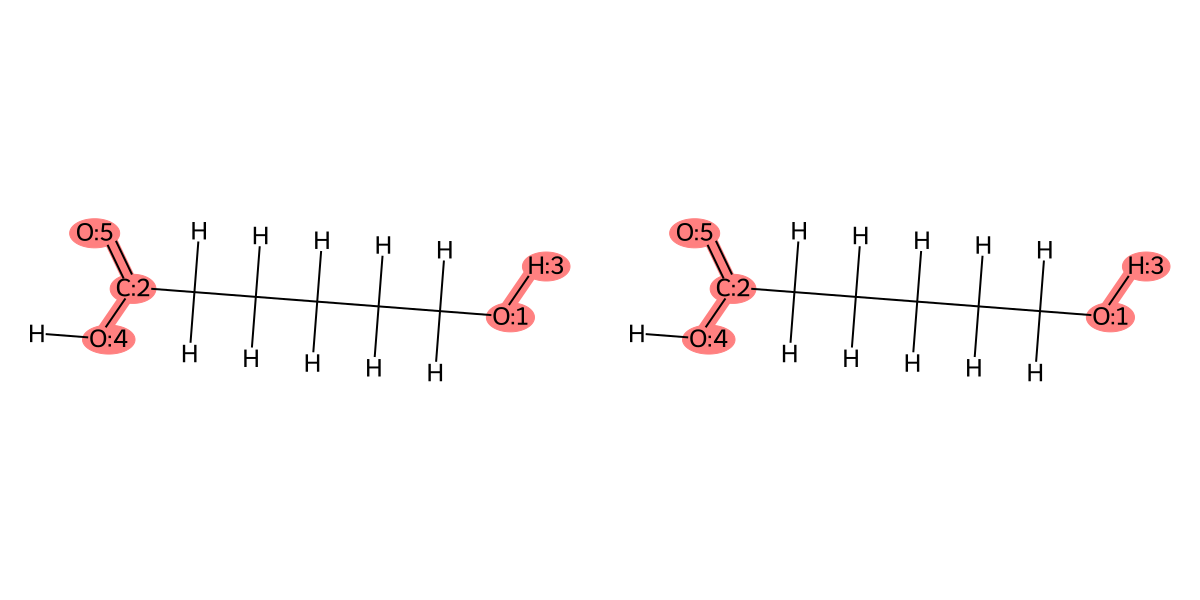

In [45]:
for test in reactions_definitions.values():
    rxn_smarts = test["reaction"]
    same_reactants = test["same_reactants"]
    reactant_smiles_1 = sample_smiles[0]
    if not same_reactants:
        reactant_smiles_2 = sample_smiles[1]  # For testing, use the same sample
    mapped_reactants, products = map_reactant_atoms(
        rxn_smarts,
        same_reactants,
        reactant_smiles_1,
        reactant_smiles_2 if not same_reactants else reactant_smiles_1
    )
# Visualize mapped reactants with highlighted mapped atoms
img = Draw.MolsToGridImage(
    [mol for pair in mapped_reactants for mol in pair],
    molsPerRow=2,
    subImgSize=(600, 600),
    highlightAtomLists=[
        [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomMapNum() != 0]
        for pair in mapped_reactants for mol in pair
    ]
)
display(img)


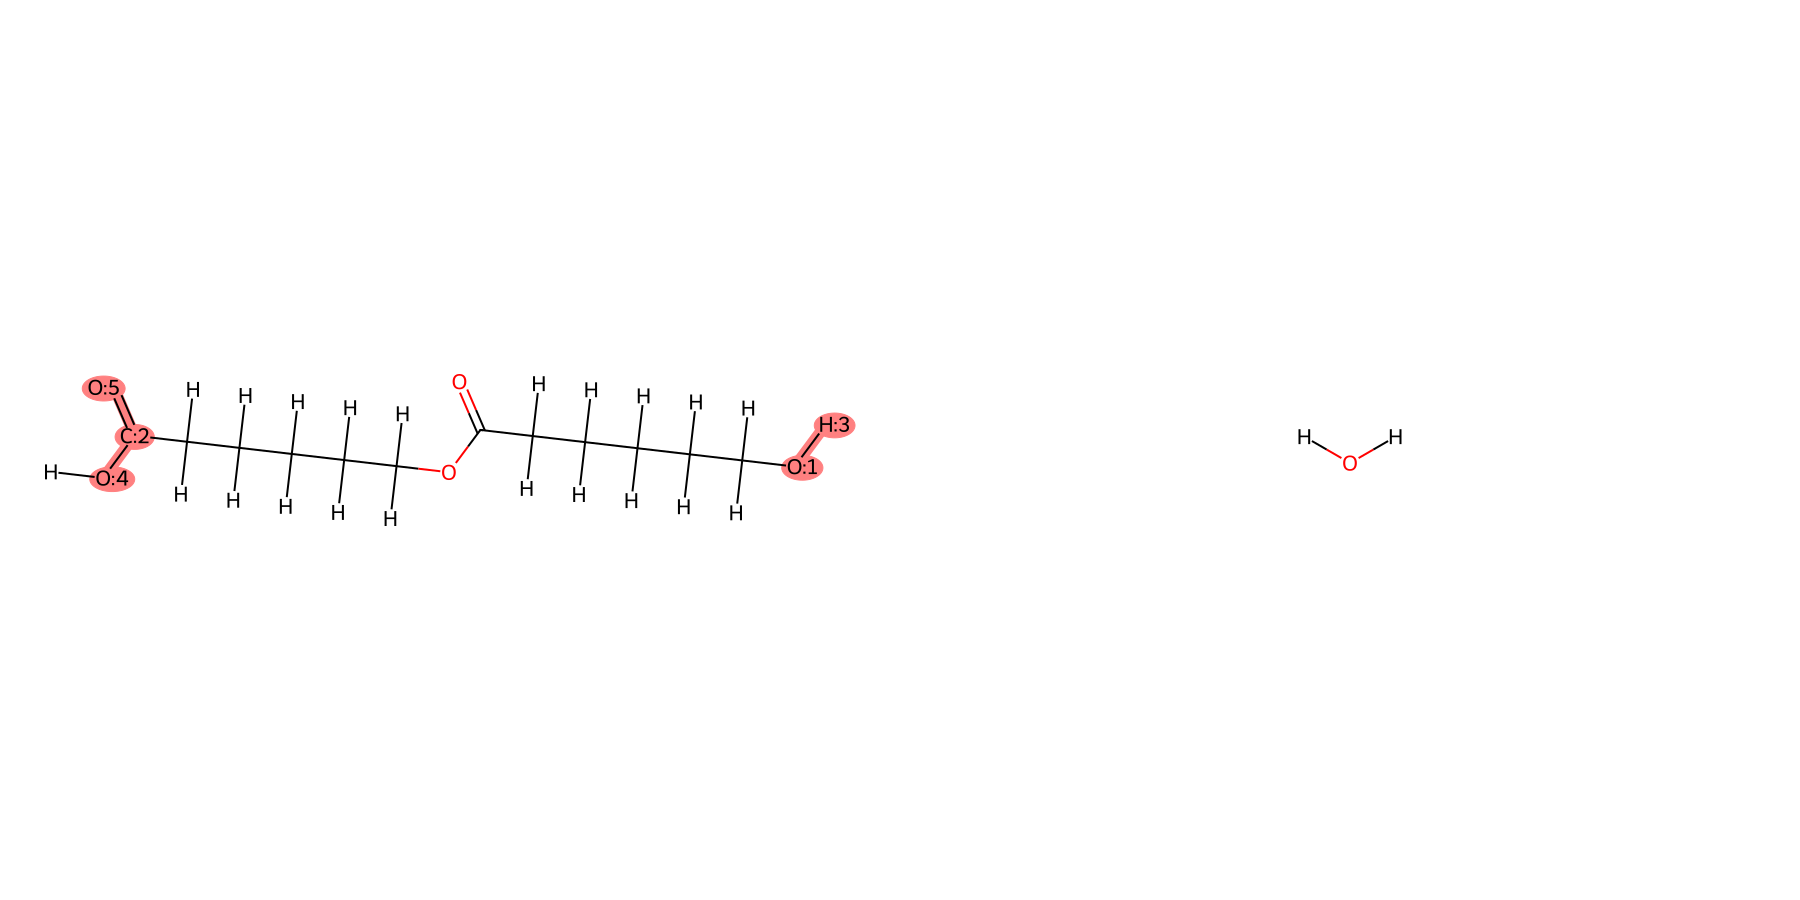

In [49]:
for product_set in products:
    img = Draw.MolsToGridImage(
        product_set,
        molsPerRow=2,
        subImgSize=(900, 900),
        highlightAtomLists=[
            [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomMapNum() != 0]
            for mol in product_set
        ]
    )
    display(img)